# КИМ 2.1. Backprop и обучение сети — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-02-backprop-training.ipynb`](./kim-02-backprop-training.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В этом эталоне:
- **Часть А** — backprop вручную на чистом NumPy;
- **Части Б и В** — та же задача на PyTorch с автодифференцированием.

Fashion-MNIST загружается один раз через `torchvision`, после чего часть А работает
только с массивами NumPy.

---
## Часть А. Backprop на чистом NumPy (обязательно)

Архитектура: $784 \rightarrow 64\ (\mathrm{ReLU}) \rightarrow 10\ (\mathrm{softmax})$.
Все производные и обновления параметров в этой части реализованы вручную, без
автодифференцирования.

### 0. Импорт и подмножество Fashion-MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
%matplotlib inline

SEED = 42
np.random.seed(SEED)

# torchvision хранит изображения и метки как torch.Tensor. Для ручной части
# сразу извлекаем NumPy-массивы и больше не используем операции PyTorch.
fashion_train = datasets.FashionMNIST(root='./data', train=True, download=True)
x_full = fashion_train.data.numpy().astype(np.float32) / 255.0
y_full = fashion_train.targets.numpy()

N = 10_000
subset_idx = np.random.choice(len(x_full), N, replace=False)
X = x_full[subset_idx].reshape(N, 784)
labels = y_full[subset_idx]
y = np.eye(10, dtype=np.float32)[labels]

split = int(0.8 * N)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
y_train_idx, y_val_idx = labels[:split], labels[split:]
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(8000, 784) (8000, 10) (2000, 784) (2000, 10)


### 1. Инициализация параметров (He для ReLU)

In [2]:
def init_params():
    W1 = (np.random.randn(784, 64) * np.sqrt(2.0 / 784)).astype(np.float32)
    b1 = np.zeros(64, dtype=np.float32)
    W2 = (np.random.randn(64, 10) * np.sqrt(2.0 / 64)).astype(np.float32)
    b2 = np.zeros(10, dtype=np.float32)
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()

### 2. Прямой проход

In [3]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1        # (B, 64)
    a1 = relu(z1)           # (B, 64)
    z2 = a1 @ W2 + b2       # (B, 10)
    y_hat = softmax(z2)     # (B, 10)
    return z1, a1, z2, y_hat

### 3. Функция потерь — кросс-энтропия

In [4]:
def cross_entropy(y_hat, y):
    eps = 1e-12
    return -np.sum(y * np.log(y_hat + eps)) / len(y)

### 4. Обратный проход

Для softmax и cross-entropy совместная производная по логитам равна
$\partial L / \partial z_2 = (\hat{y} - y) / B$. Затем градиент передаётся
назад через второй линейный слой и ReLU.

In [5]:
def backward(X, y, z1, a1, y_hat, W2):
    B = len(X)
    dz2 = (y_hat - y) / B                   # (B, 10)
    dW2 = a1.T @ dz2                        # (64, 10)
    db2 = np.sum(dz2, axis=0)               # (10,)
    da1 = dz2 @ W2.T                        # (B, 64)
    dz1 = da1 * (z1 > 0)                    # производная ReLU
    dW1 = X.T @ dz1                         # (784, 64)
    db1 = np.sum(dz1, axis=0)               # (64,)
    return dW1, db1, dW2, db2

### 5. Обучение ручной сети

In [6]:
def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = np.random.permutation(len(X)) if shuffle else np.arange(len(X))
    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices]

lr = 0.1
epochs = 50
batch_size = 64
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    for xb, yb in iterate_minibatches(X_train, y_train, batch_size):
        z1, a1, z2, y_hat = forward(xb, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(xb, yb, z1, a1, y_hat, W2)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    _, _, _, train_prob = forward(X_train, W1, b1, W2, b2)
    _, _, _, val_prob = forward(X_val, W1, b1, W2, b2)
    train_losses.append(cross_entropy(train_prob, y_train))
    val_losses.append(cross_entropy(val_prob, y_val))
    train_accs.append(np.mean(train_prob.argmax(axis=1) == y_train_idx))
    val_accs.append(np.mean(val_prob.argmax(axis=1) == y_val_idx))

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха {epoch + 1:2d}: train_loss={train_losses[-1]:.4f}  '
              f'val_loss={val_losses[-1]:.4f}  val_acc={val_accs[-1]:.4f}')

print(f'Итоговая val_acc NumPy: {val_accs[-1]:.4f}')

Эпоха  5: train_loss=0.4526  val_loss=0.5014  val_acc=0.8335


Эпоха 10: train_loss=0.3877  val_loss=0.4630  val_acc=0.8315


Эпоха 15: train_loss=0.3152  val_loss=0.4274  val_acc=0.8510


Эпоха 20: train_loss=0.2960  val_loss=0.4337  val_acc=0.8550


Эпоха 25: train_loss=0.2581  val_loss=0.4155  val_acc=0.8555


Эпоха 30: train_loss=0.2290  val_loss=0.4168  val_acc=0.8625


Эпоха 35: train_loss=0.2485  val_loss=0.4560  val_acc=0.8445


Эпоха 40: train_loss=0.2011  val_loss=0.4353  val_acc=0.8560


Эпоха 45: train_loss=0.1708  val_loss=0.4300  val_acc=0.8620


Эпоха 50: train_loss=0.1706  val_loss=0.4558  val_acc=0.8535
Итоговая val_acc NumPy: 0.8535


Пятьдесят эпох соответствуют требуемому диапазону 50–100 эпох для
ручной сети. При фиксированном seed итоговая `val_acc` обычно находится примерно
в диапазоне **0.83–0.85**. Небольшие отличия возможны между версиями NumPy и
BLAS.

### 6. Кривые обучения

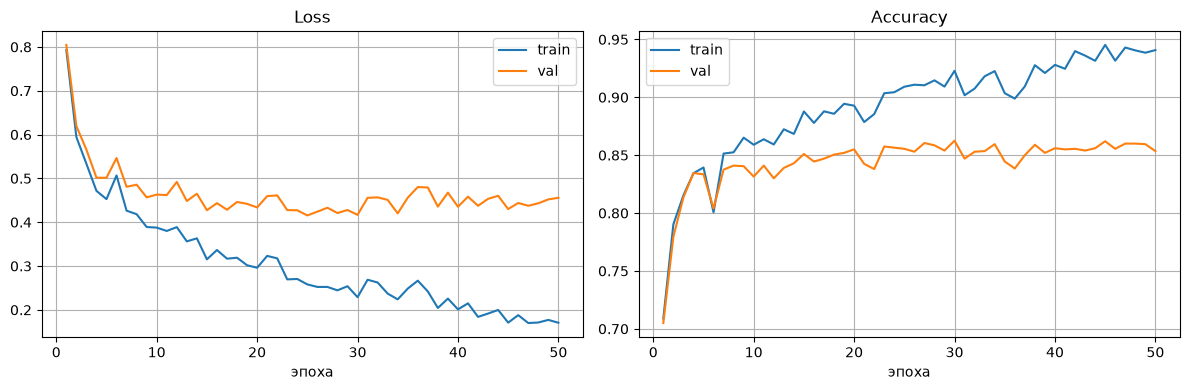

In [7]:
numpy_epochs = np.arange(1, epochs + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(numpy_epochs, train_losses, label='train')
ax[0].plot(numpy_epochs, val_losses, label='val')
ax[0].set_title('Loss')
ax[1].plot(numpy_epochs, train_accs, label='train')
ax[1].plot(numpy_epochs, val_accs, label='val')
ax[1].set_title('Accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Правило цепи.** Для матричной записи с объектами в строках:
$dW_2 = a_1^T dz_2$, $da_1 = dz_2 W_2^T$,
$dz_1 = da_1 \odot \mathbb{1}[z_1 > 0]$ и $dW_1 = X^T dz_1$.
Именно эта последовательность реализована в `backward`; матрица `W2`, нужная для
передачи градиента, передаётся в функцию явно.

---
## Часть Б. Явный цикл обучения на PyTorch

PyTorch автоматически вычисляет градиенты, но сам цикл обучения остаётся явным.
Последний слой возвращает **сырые логиты**: `CrossEntropyLoss` сам применяет
численно устойчивый `log_softmax`, поэтому `Softmax` в модель добавлять нельзя.

### 7. Устройство, seed и тензоры

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, TensorDataset

def set_torch_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_torch_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print('Устройство:', device)

X_tr_t = torch.from_numpy(X_train).float()
y_tr_t = torch.from_numpy(y_train_idx).long()
X_va_t = torch.from_numpy(X_val).float()
y_va_t = torch.from_numpy(y_val_idx).long()
torch_train_ds = TensorDataset(X_tr_t, y_tr_t)

def make_loader(dataset, batch_size, seed=42):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        pin_memory=torch.cuda.is_available(),
    )

Устройство: cuda


### Модель, оценка и пять шагов обучения

PyTorch: val_loss=0.4456, val_acc=0.8475


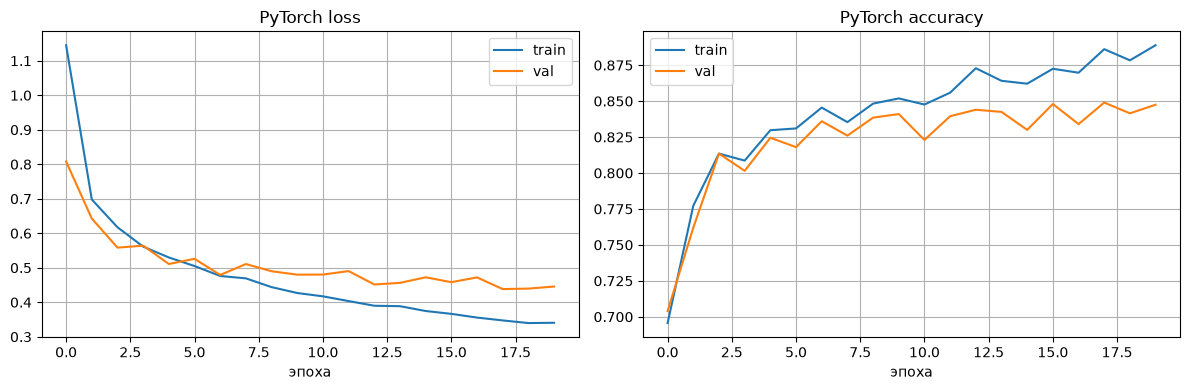

In [9]:
def make_model():
    return nn.Sequential(
        nn.Linear(784, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )

def evaluate(model, X, y, criterion, device):
    model.eval()
    with torch.no_grad():
        X_device = X.to(device)
        y_device = y.to(device)
        logits = model(X_device)
        loss = criterion(logits, y_device).item()
        accuracy = (logits.argmax(dim=1) == y_device).float().mean().item()
    return loss, accuracy

def train_pytorch(model, loader, criterion, optimizer, device, epochs, X_val, y_val):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    X_train_eval, y_train_eval = loader.dataset.tensors

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()             # 1. Обнулить старые градиенты
            logits = model(xb)                # 2. Прямой проход: сырые логиты
            loss = criterion(logits, yb)      # 3. Вычислить loss
            loss.backward()                   # 4. Обратный проход
            optimizer.step()                  # 5. Обновить параметры
            total_loss += loss.item() * len(xb)

        _, train_acc = evaluate(model, X_train_eval, y_train_eval, criterion, device)
        val_loss, val_acc = evaluate(model, X_val, y_val, criterion, device)
        history['train_loss'].append(total_loss / len(loader.dataset))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

    return history

set_torch_seed(SEED)
model = make_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
train_loader = make_loader(torch_train_ds, batch_size=64, seed=SEED)
history = train_pytorch(
    model, train_loader, criterion, optimizer, device,
    epochs=20, X_val=X_va_t, y_val=y_va_t,
)

val_loss, val_acc = evaluate(model, X_va_t, y_va_t, criterion, device)
print(f'PyTorch: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('PyTorch loss')
ax[1].plot(history['train_acc'], label='train')
ax[1].plot(history['val_acc'], label='val')
ax[1].set_title('PyTorch accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

### 8. Сравнение размеров пакета 10 / 50 / 200 / 500

batch_size= 10: val_loss=0.4513, val_acc=0.8505


batch_size= 50: val_loss=0.5112, val_acc=0.8320


batch_size=200: val_loss=0.5316, val_acc=0.8105


batch_size=500: val_loss=0.6302, val_acc=0.7960


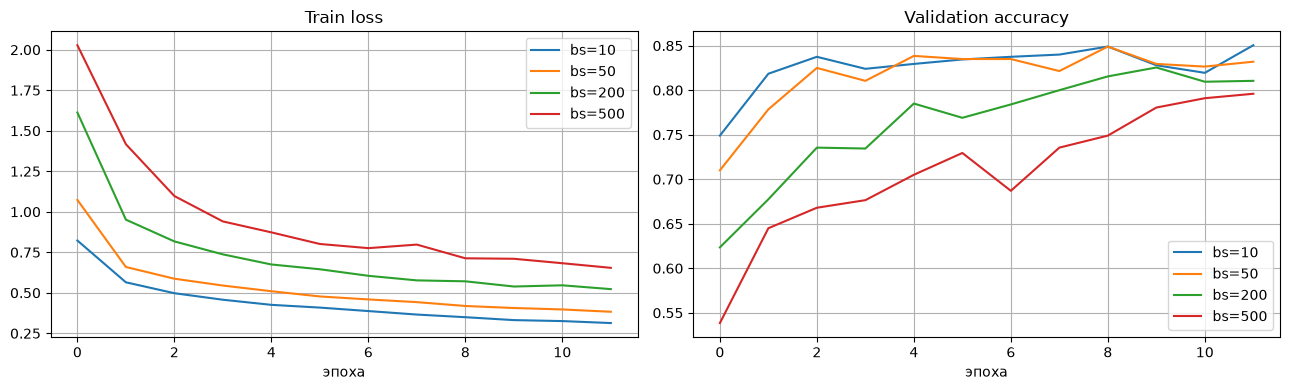

In [10]:
batch_sizes = [10, 50, 200, 500]
comparison = {}
comparison_epochs = 12

for batch_size in batch_sizes:
    # Одинаковый seed даёт моделям одинаковую начальную инициализацию.
    set_torch_seed(SEED)
    batch_model = make_model().to(device)
    batch_optimizer = optim.SGD(batch_model.parameters(), lr=0.1)
    batch_loader = make_loader(torch_train_ds, batch_size=batch_size, seed=SEED)
    batch_history = train_pytorch(
        batch_model, batch_loader, criterion, batch_optimizer, device,
        epochs=comparison_epochs, X_val=X_va_t, y_val=y_va_t,
    )
    comparison[batch_size] = batch_history
    print(f'batch_size={batch_size:3d}: '
          f'val_loss={batch_history["val_loss"][-1]:.4f}, '
          f'val_acc={batch_history["val_acc"][-1]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for batch_size, batch_history in comparison.items():
    ax[0].plot(batch_history['train_loss'], label=f'bs={batch_size}')
    ax[1].plot(batch_history['val_acc'], label=f'bs={batch_size}')
ax[0].set_title('Train loss')
ax[1].set_title('Validation accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Вывод:** малые пакеты выполняют больше шумных обновлений за эпоху и
обычно быстрее улучшают метрики в пересчёте на эпохи. Большие пакеты дают более
гладкие, но более редкие обновления. Для сравнения времени нужно также учитывать,
что эпоха с `batch_size=10` содержит намного больше шагов оптимизатора.

### 9. Выбор активации, инициализации и связности

Сравниваем три конфигурации при одинаковых seed, optimizer, batch size и числе
эпох. Инициализация выбирается согласованно с активацией: He для ReLU, Xavier
для tanh. Число скрытых слоёв задаёт различную степень связности модели.

In [11]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_sizes, activation):
        super().__init__()
        activation_factory = nn.ReLU if activation == 'relu' else nn.Tanh
        layers = []
        in_features = 784
        for hidden_size in hidden_sizes:
            linear = nn.Linear(in_features, hidden_size)
            if activation == 'relu':
                nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')
            else:
                nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.extend([linear, activation_factory()])
            in_features = hidden_size
        output = nn.Linear(in_features, 10)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


configuration_specs = [
    ('ReLU + He, 1 слой', [64], 'relu'),
    ('tanh + Xavier, 1 слой', [64], 'tanh'),
    ('ReLU + He, 2 слоя', [128, 64], 'relu'),
]
configuration_results = []
configuration_ds = TensorDataset(X_tr_t[:4_000], y_tr_t[:4_000])

for name, hidden_sizes, activation in configuration_specs:
    set_torch_seed(SEED)
    configuration_model = ConfigurableMLP(hidden_sizes, activation).to(device)
    configuration_loader = make_loader(configuration_ds, batch_size=64, seed=SEED)
    configuration_optimizer = optim.SGD(configuration_model.parameters(), lr=0.05)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    started = time.perf_counter()
    configuration_history = train_pytorch(
        configuration_model, configuration_loader, criterion,
        configuration_optimizer, device, epochs=6, X_val=X_va_t, y_val=y_va_t,
    )
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    parameters = sum(p.numel() for p in configuration_model.parameters())
    configuration_results.append({
        'конфигурация': name,
        'val_loss': configuration_history['val_loss'][-1],
        'val_accuracy': configuration_history['val_acc'][-1],
        'параметры': parameters,
        'секунды': elapsed,
    })

print(f"{'Конфигурация':<28} {'val loss':>10} {'val acc':>10} "
      f"{'параметры':>12} {'секунды':>9}")
for row in configuration_results:
    print(f"{row['конфигурация']:<28} {row['val_loss']:>10.4f} "
          f"{row['val_accuracy']:>10.4f} {row['параметры']:>12,} "
          f"{row['секунды']:>9.2f}")

best_configuration = max(configuration_results, key=lambda row: row['val_accuracy'])
print('Выбрана по validation accuracy:', best_configuration['конфигурация'])

Конфигурация                   val loss    val acc    параметры   секунды
ReLU + He, 1 слой                0.7144     0.7420       50,890      0.88
tanh + Xavier, 1 слой            0.6128     0.7820       50,890      0.85
ReLU + He, 2 слоя                0.6616     0.7600      109,386      0.94
Выбрана по validation accuracy: tanh + Xavier, 1 слой


Выбор выполняется только по validation accuracy. Test не участвует в
сравнении конфигураций. ReLU с He обычно лучше сохраняет масштаб сигнала в
глубоких ReLU-сетях, а Xavier соответствует симметричной tanh. Второй скрытый
слой увеличивает выразительность и число параметров, но не гарантирует лучшую
валидацию.

---
## Часть В. Переобучение и регуляризация

Чтобы получить заметное переобучение без лишнего времени работы, используем сеть,
число параметров которой существенно больше числа обучающих объектов, и фиксируем
подвыборки из 800 train и 1 000 validation объектов. Один непрерывный запуск без
регуляризации до 200 эпох точно покрывает checkpoints 10 / 50 / 100 / 200.
Dropout и L2 запускаются отдельно в том же протоколе.

### 10. Единый протокол эксперимента до 200 эпох

In [12]:
import copy

PART_C_TRAIN_SIZE = 800
PART_C_VAL_SIZE = 1_000
PART_C_EPOCHS = 200
PART_C_BATCH_SIZE = 128
CHECKPOINT_EPOCHS = (10, 50, 100, 200)
EARLY_STOPPING_PATIENCE = 15

part_c_ds = TensorDataset(
    X_tr_t[:PART_C_TRAIN_SIZE],
    y_tr_t[:PART_C_TRAIN_SIZE],
)
X_part_c, y_part_c = part_c_ds.tensors
X_part_c_val = X_va_t[:PART_C_VAL_SIZE]
y_part_c_val = y_va_t[:PART_C_VAL_SIZE]


def make_part_c_model(dropout=0.0):
    layers = [nn.Linear(784, 128), nn.ReLU()]
    if dropout > 0:
        layers.append(nn.Dropout(dropout))
    layers.extend([nn.Linear(128, 64), nn.ReLU()])
    if dropout > 0:
        layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(64, 10))
    return nn.Sequential(*layers)


def train_part_c(name, dropout=0.0, weight_decay=0.0,
                 track_early_stopping=False):
    set_torch_seed(SEED)
    model = make_part_c_model(dropout).to(device)
    loader = make_loader(part_c_ds, batch_size=PART_C_BATCH_SIZE, seed=SEED)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # Параллельно с полным 200-эпоховым прогоном фиксируем точный момент, когда
    # EarlyStopping остановил бы ту же базовую траекторию, и его лучшие веса.
    es_best_loss = float('inf')
    es_best_epoch = 0
    es_best_state = copy.deepcopy(model.state_dict())
    es_bad_epochs = 0
    es_stop_epoch = None

    for epoch in range(1, PART_C_EPOCHS + 1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(
            model, X_part_c, y_part_c, criterion, device,
        )
        val_loss, val_acc = evaluate(
            model, X_part_c_val, y_part_c_val, criterion, device,
        )
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if track_early_stopping and es_stop_epoch is None:
            if val_loss < es_best_loss:
                es_best_loss = val_loss
                es_best_epoch = epoch
                es_best_state = copy.deepcopy(model.state_dict())
                es_bad_epochs = 0
            else:
                es_bad_epochs += 1
                if es_bad_epochs >= EARLY_STOPPING_PATIENCE:
                    es_stop_epoch = epoch

        if epoch in CHECKPOINT_EPOCHS:
            print(
                f'{name:<18} epoch={epoch:3d}: '
                f'train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, '
                f'train_acc={train_acc:.4f}, val_acc={val_acc:.4f}'
            )

    if es_stop_epoch is None:
        es_stop_epoch = PART_C_EPOCHS

    return {
        'history': history,
        'es_stop_epoch': es_stop_epoch,
        'es_best_epoch': es_best_epoch,
        'es_best_state': es_best_state,
    }


part_c_runs = {
    'Без регуляризации': train_part_c(
        'Без регуляризации', track_early_stopping=True,
    ),
    'Dropout': train_part_c('Dropout', dropout=0.4),
    'L2': train_part_c('L2', weight_decay=1e-4),
}

Без регуляризации  epoch= 10: train_loss=0.5839, val_loss=0.7629, train_acc=0.7950, val_acc=0.7440


Без регуляризации  epoch= 50: train_loss=0.1655, val_loss=0.6598, train_acc=0.9475, val_acc=0.8040


Без регуляризации  epoch=100: train_loss=0.0376, val_loss=0.8730, train_acc=0.9937, val_acc=0.8010


Без регуляризации  epoch=200: train_loss=0.0029, val_loss=1.1802, train_acc=1.0000, val_acc=0.7980


Dropout            epoch= 10: train_loss=0.7301, val_loss=0.8595, train_acc=0.7237, val_acc=0.6790


...

Dropout            epoch=200: train_loss=0.0143, val_loss=0.9807, train_acc=1.0000, val_acc=0.8040


L2                 epoch= 10: train_loss=0.5846, val_loss=0.7653, train_acc=0.7937, val_acc=0.7380


L2                 epoch= 50: train_loss=0.1609, val_loss=0.6666, train_acc=0.9475, val_acc=0.8010


L2                 epoch=100: train_loss=0.0339, val_loss=0.8802, train_acc=0.9962, val_acc=0.8010


L2                 epoch=200: train_loss=0.0036, val_loss=1.1310, train_acc=1.0000, val_acc=0.7960


`Dropout(0.4)` и `weight_decay=1e-4` зафиксированы до запуска как
типичные стартовые значения, а не выбраны по полученной validation-таблице.
Архитектура, данные, инициализация, порядок mini-batches, optimizer и бюджет эпох
не меняются, поэтому разница метрик относится к исследуемому методу. Улучшение
не предполагается заранее: если строка метода хуже baseline, этот метод при
данной настройке отвергается или настраивается в отдельном validation-протоколе.

### 11. Checkpoints 10 / 50 / 100 / 200 и признаки переобучения

 Эпоха  train loss   val loss  train acc   val acc   acc gap
    10      0.5839     0.7629     0.7950    0.7440    0.0510
    50      0.1655     0.6598     0.9475    0.8040    0.1435
   100      0.0376     0.8730     0.9937    0.8010    0.1927
   200      0.0029     1.1802     1.0000    0.7980    0.2020
Минимальная val_loss достигнута на эпохе 28.
Рост val_loss от минимума к эпохе 200: +0.5666


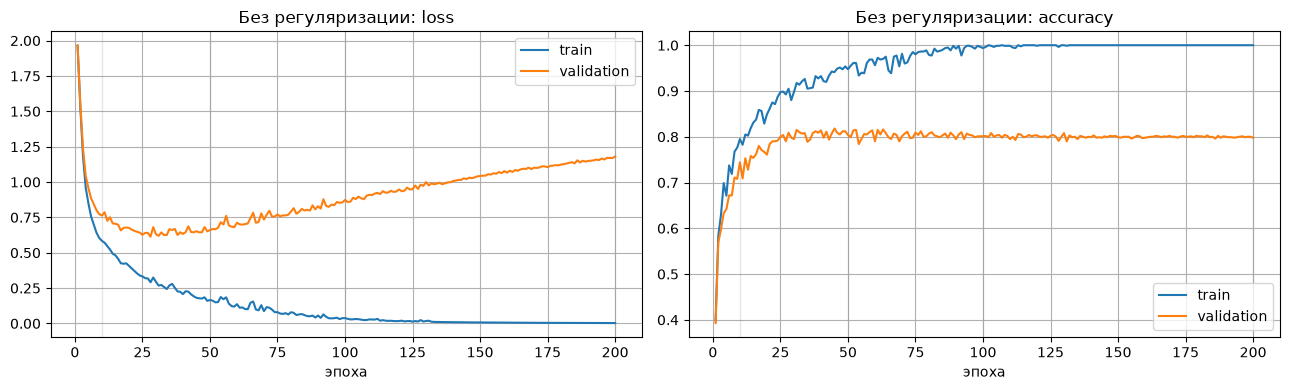

In [13]:
baseline_history = part_c_runs['Без регуляризации']['history']

print(f"{'Эпоха':>6} {'train loss':>11} {'val loss':>10} "
      f"{'train acc':>10} {'val acc':>9} {'acc gap':>9}")
for epoch in CHECKPOINT_EPOCHS:
    i = epoch - 1
    gap = baseline_history['train_acc'][i] - baseline_history['val_acc'][i]
    print(
        f"{epoch:>6d} {baseline_history['train_loss'][i]:>11.4f} "
        f"{baseline_history['val_loss'][i]:>10.4f} "
        f"{baseline_history['train_acc'][i]:>10.4f} "
        f"{baseline_history['val_acc'][i]:>9.4f} {gap:>9.4f}"
    )

best_baseline_epoch = int(np.argmin(baseline_history['val_loss'])) + 1
val_loss_growth = (
    baseline_history['val_loss'][-1]
    - baseline_history['val_loss'][best_baseline_epoch - 1]
)
print(f'Минимальная val_loss достигнута на эпохе {best_baseline_epoch}.')
print(f'Рост val_loss от минимума к эпохе 200: {val_loss_growth:+.4f}')

epochs_part_c = np.arange(1, PART_C_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(epochs_part_c, baseline_history['train_loss'], label='train')
ax[0].plot(epochs_part_c, baseline_history['val_loss'], label='validation')
ax[0].set_title('Без регуляризации: loss')
ax[1].plot(epochs_part_c, baseline_history['train_acc'], label='train')
ax[1].plot(epochs_part_c, baseline_history['val_acc'], label='validation')
ax[1].set_title('Без регуляризации: accuracy')
for a in ax:
    for checkpoint in CHECKPOINT_EPOCHS:
        a.axvline(checkpoint, color='grey', alpha=0.2, linewidth=1)
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

Переобучение подтверждается не одной финальной цифрой, а динамикой:
train loss продолжает падать и разрыв train/validation accuracy увеличивается,
тогда как validation loss после своего минимума растёт или стагнирует. Таблица и
вертикальные линии позволяют проверить это именно на требуемых длительностях.

### 12. Раздельное сравнение Dropout, L2 и EarlyStopping

EarlyStopping оценивается без дублирования базового обучения: как
только исчерпана `patience`, фиксируются эпоха остановки и лучшие на тот момент
веса. Базовый цикл продолжает выполняться только ради обязательного checkpoint
200; метрики строки EarlyStopping вычисляются после восстановления зафиксированных
весов, поэтому совпадают с отдельным запуском при тех же seed и порядке batches.

In [14]:
baseline_run = part_c_runs['Без регуляризации']
early_stopped_model = make_part_c_model().to(device)
early_stopped_model.load_state_dict(baseline_run['es_best_state'])
es_train_loss, es_train_acc = evaluate(
    early_stopped_model, X_part_c, y_part_c, criterion, device,
)
es_val_loss, es_val_acc = evaluate(
    early_stopped_model, X_part_c_val, y_part_c_val, criterion, device,
)


def final_row(method, run):
    history = run['history']
    return {
        'method': method,
        'trained_epochs': PART_C_EPOCHS,
        'selected_epoch': PART_C_EPOCHS,
        'train_loss': history['train_loss'][-1],
        'val_loss': history['val_loss'][-1],
        'train_acc': history['train_acc'][-1],
        'val_acc': history['val_acc'][-1],
    }


regularization_rows = [
    final_row('Без регуляризации', part_c_runs['Без регуляризации']),
    final_row('Только Dropout(0.4)', part_c_runs['Dropout']),
    final_row('Только L2(1e-4)', part_c_runs['L2']),
    {
        'method': f'EarlyStopping(patience={EARLY_STOPPING_PATIENCE})',
        'trained_epochs': baseline_run['es_stop_epoch'],
        'selected_epoch': baseline_run['es_best_epoch'],
        'train_loss': es_train_loss,
        'val_loss': es_val_loss,
        'train_acc': es_train_acc,
        'val_acc': es_val_acc,
    },
]

baseline_val_acc = regularization_rows[0]['val_acc']
print(f"{'Метод':<28} {'эпох':>5} {'выбрана':>7} {'val loss':>9} "
      f"{'val acc':>8} {'acc gap':>8} {'Δ val acc':>10}")
for row in regularization_rows:
    accuracy_gap = row['train_acc'] - row['val_acc']
    val_accuracy_delta = row['val_acc'] - baseline_val_acc
    print(
        f"{row['method']:<28} {row['trained_epochs']:>5d} "
        f"{row['selected_epoch']:>7d} {row['val_loss']:>9.4f} "
        f"{row['val_acc']:>8.4f} {accuracy_gap:>8.4f} "
        f"{val_accuracy_delta:>+10.4f}"
    )

best_method = max(regularization_rows[1:], key=lambda row: row['val_acc'])
print('Лучшая отдельная регуляризация по val accuracy:', best_method['method'])
print(
    f"EarlyStopping остановил бы обучение на эпохе "
    f"{baseline_run['es_stop_epoch']} и восстановил веса эпохи "
    f"{baseline_run['es_best_epoch']}."
)

Метод                         эпох выбрана  val loss  val acc  acc gap  Δ val acc
Без регуляризации              200     200    1.1802   0.7980   0.2020    +0.0000
Только Dropout(0.4)            200     200    0.9807   0.8040   0.1960    +0.0060
Только L2(1e-4)                200     200    1.1310   0.7960   0.2040    -0.0020
EarlyStopping(patience=15)      43      28    0.6137   0.8090   0.0960    +0.0110
Лучшая отдельная регуляризация по val accuracy: EarlyStopping(patience=15)
EarlyStopping остановил бы обучение на эпохе 43 и восстановил веса эпохи 28.


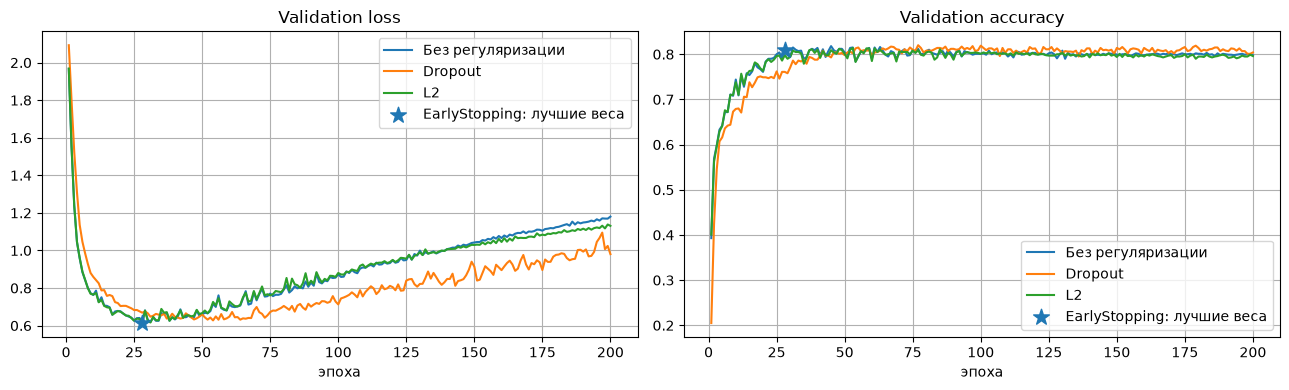

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, run in part_c_runs.items():
    history = run['history']
    ax[0].plot(epochs_part_c, history['val_loss'], label=name)
    ax[1].plot(epochs_part_c, history['val_acc'], label=name)

es_epoch = baseline_run['es_best_epoch']
ax[0].scatter(es_epoch, es_val_loss, marker='*', s=140,
              label='EarlyStopping: лучшие веса', zorder=5)
ax[1].scatter(es_epoch, es_val_acc, marker='*', s=140,
              label='EarlyStopping: лучшие веса', zorder=5)
ax[0].set_title('Validation loss')
ax[1].set_title('Validation accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Вывод по эксперименту.** Методы не объединены: эффект каждого
виден в отдельной строке и на общей validation-кривой. Dropout в train случайно
зануляет активации, L2 штрафует большие веса, а EarlyStopping не меняет loss, но
останавливает базовую траекторию после 15 эпох без улучшения и восстанавливает её
лучшие веса. Конкретный выбор делается по напечатанным `val_acc`, `val_loss`,
разрыву train/validation и экономии эпох, а не предполагается заранее.